# Выявление мошенничества в банковских транзакциях

## Введение

С развитием онлайн-банкинга и цифровых финансовых операций количество банковских транзакций значительно увеличилось. Одновременно с этим растёт и число мошеннических операций, которые могут приводить к финансовым потерям для банков и их клиентов.

Финансовые организации активно используют методы анализа данных и машинного обучения для выявления подозрительных транзакций и предотвращения мошенничества.

Цель данного проекта — провести исследовательский анализ транзакционных данных клиентов банка, выявить закономерности, связанные с мошенническими операциями, и подготовить данные для последующего построения моделей машинного обучения.

Основная задача проекта — классификация транзакций на:
- легитимные
- мошеннические

Целевая переменная датасета — **Is_Fraud**.

---

## Описание набора данных

Данный набор данных содержит информацию о транзакциях клиентов банка, включая сведения о клиентах, параметрах транзакций, устройствах, используемых для операций, и характеристиках продавцов.

Каждая строка датасета представляет одну банковскую транзакцию.

Набор данных включает следующие категории признаков:

### Информация о клиенте

- **Customer_ID** — уникальный идентификатор клиента  
- **Customer_Name** — имя клиента  
- **Gender** — пол клиента  
- **Age** — возраст клиента  
- **State** — страна проживания клиента  
- **City** — город проживания клиента  
- **Bank_Branch** — отделение банка  
- **Account_Type** — тип банковского счета  

### Информация о транзакции

- **Transaction_ID** — уникальный идентификатор транзакции  
- **Transaction_Date** — дата транзакции  
- **Transaction_Time** — время транзакции  
- **Transaction_Amount** — сумма транзакции  
- **Transaction_Type** — тип транзакции (снятие средств, перевод, пополнение и др.)

### Информация о продавце

- **Merchant_ID** — идентификатор продавца  
- **Merchant_Category** — категория продавца  

### Техническая информация о транзакции

- **Transaction_Device** — устройство, использованное для транзакции  
- **Device_Type** — тип устройства  
- **Transaction_Location** — географическое местоположение транзакции  
- **Transaction_Currency** — валюта транзакции  

### Финансовая информация

- **Account_Balance** — баланс счета клиента после совершения транзакции  

### Контактная информация клиента

- **Customer_Contact** — номер телефона клиента  
- **Customer_Email** — электронная почта клиента  

### Целевая переменная

- **Is_Fraud** — индикатор мошенничества
  - **0** — легитимная транзакция
  - **1** — мошенническая транзакция

---

## Цель анализа

Основные цели данного анализа:

- провести исследовательский анализ данных (EDA)
- изучить распределение мошеннических транзакций
- выявить потенциальные факторы, связанные с мошенничеством
- подготовить данные для последующего построения моделей машинного обучения

---

## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

## Загрузка данных

In [2]:
df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

### Функции

In [3]:
def numerical_distribution(num, title, x, y):
    df[num].plot(kind='hist', bins = 20)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)

In [4]:
def category_distribution(category, title, x, y):
    df[category].value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)

## Первичный обзор данных

In [5]:
df.shape

(200000, 24)

In [6]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Merchant_ID,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,16:04:07,32415.45,214e03c5-5c34-40d1-a66c-f440aa2bbd02,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,17:14:53,43622.60,f9e3f11f-28d3-4199-b0ca-f225a155ede6,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,03:09:52,63062.56,97977d83-5486-4510-af1c-8dada3e1cfa0,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,12:27:02,14000.72,f45cd6b3-5092-44d0-8afb-490894605184,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,18:30:46,18335.16,70dd77dd-3b00-4b2c-8ebc-cfb8af5f6741,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

### Проверка структуры данных

Метод `df.info()` показывает типы данных, количество наблюдений и наличие пропущенных значений.

Анализ структуры данных показывает, что датасет содержит **200 000 транзакций и 24 признака**.  
Пропущенные значения в данных отсутствуют, что упрощает дальнейший анализ.

---

## Анализ целевой переменной

In [8]:
df['Is_Fraud'].value_counts()

Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

In [9]:
df['Is_Fraud'].value_counts(normalize=True) * 100

Is_Fraud
0    94.956
1     5.044
Name: proportion, dtype: float64

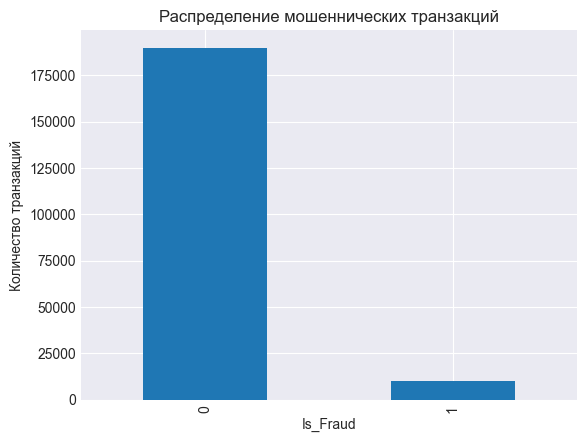

In [10]:
category_distribution('Is_Fraud', 'Распределение мошеннических транзакций','Is_Fraud', 'Количество транзакций')

**Вывод**

Анализ целевой переменной показывает, что подавляющее большинство транзакций в наборе данных являются легитимными. Доля мошеннических операций составляет около **5%** от общего количества транзакций.

Таким образом, в данных наблюдается **дисбаланс классов**, при котором класс обычных транзакций значительно преобладает над мошенническими. Данный фактор необходимо учитывать при дальнейшем построении моделей машинного обучения, поскольку дисбаланс может влиять на качество классификации.


## Анализ числовых признаков

### Возраст

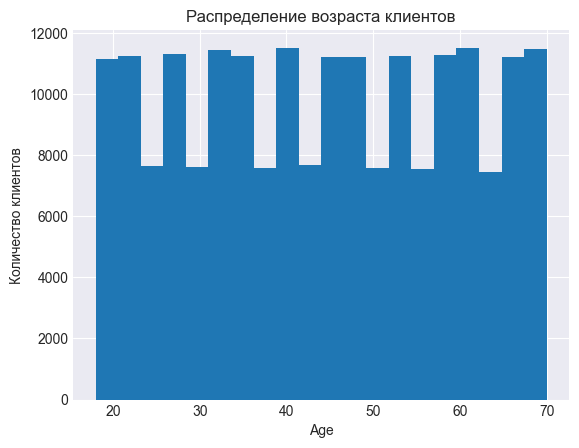

In [11]:
numerical_distribution('Age','Распределение возраста клиентов', 'Age', 'Количество клиентов')

**Вывод**

Распределение возраста клиентов показывает, что значения возраста в наборе данных распределены достаточно равномерно в диапазоне примерно от 18 до 70 лет. Выраженных пиков или концентрации клиентов в отдельных возрастных группах не наблюдается.

Таким образом, возраст клиентов представлен в данных без заметных перекосов, что позволяет использовать данный признак в дальнейшем анализе без дополнительной обработки распределения.


### Сумма транзакций

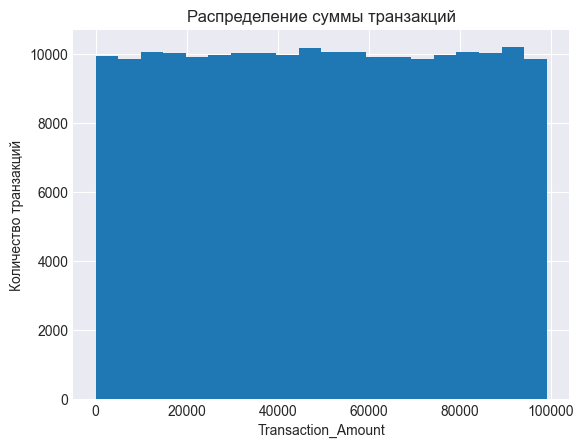

In [12]:
numerical_distribution('Transaction_Amount', 'Распределение суммы транзакций', 'Transaction_Amount', 'Количество транзакций')

**Вывод**

Распределение сумм транзакций показывает, что значения `Transaction_Amount` в наборе данных распределены достаточно равномерно в диапазоне от минимальных значений до примерно 100 000.

Выраженных пиков или концентрации транзакций в определённых диапазонах сумм не наблюдается. Это указывает на отсутствие заметных перекосов распределения данного признака в представленном наборе данных.


### Баланс счета клиента

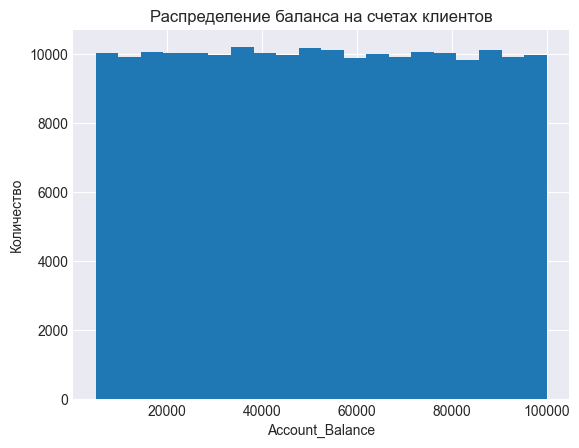

In [13]:
numerical_distribution('Account_Balance', 'Распределение баланса на счетах клиентов', 'Account_Balance', 'Количество')

**Вывод**

Анализ распределения баланса счетов клиентов показывает, что значения `Account_Balance` распределены достаточно равномерно в диапазоне от минимальных до максимальных значений. Явной концентрации клиентов в отдельных диапазонах баланса не наблюдается.

Таким образом, признак баланса счета представлен в данных без выраженных перекосов распределения и может быть использован в дальнейшем анализе для изучения возможной связи с мошенническими транзакциями.


## Анализ категориальных признаков

### Гендер

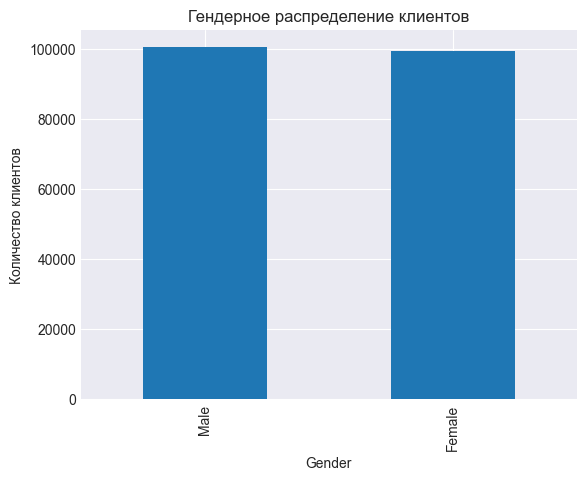

In [14]:
category_distribution('Gender', 'Гендерное распределение клиентов','Gender', 'Количество клиентов')

**Вывод**

Анализ гендерного распределения клиентов показывает, что количество мужчин и женщин в наборе данных практически одинаково. Значимого перекоса в сторону одной из категорий не наблюдается.

Таким образом, признак `Gender` представлен в данных сбалансировано и может быть использован в дальнейшем анализе без риска смещения распределения.


### Тип аккаунта

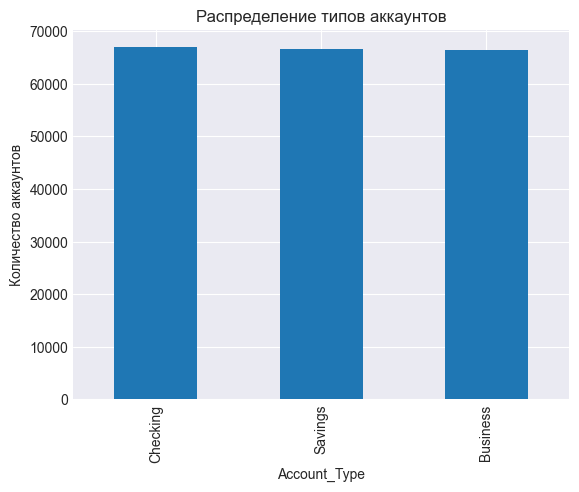

In [15]:
category_distribution('Account_Type', 'Распределение типов аккаунтов','Account_Type', 'Количество аккаунтов')

**Вывод**

Анализ распределения типов банковских счетов показывает, что в наборе данных представлены три категории аккаунтов: Checking, Savings и Business. Количество клиентов в каждой категории практически одинаково, что указывает на сбалансированное распределение типов счетов.

Таким образом, признак `Account_Type` не демонстрирует значительного доминирования какой-либо категории и может быть использован в дальнейшем анализе без риска смещения распределения.


### Тип транзакции

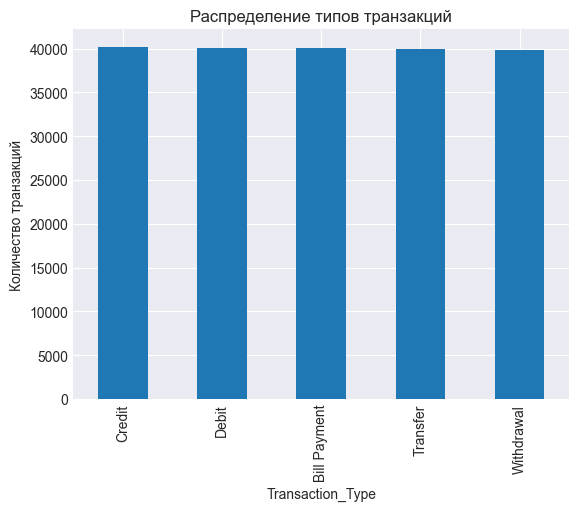

In [16]:
category_distribution('Transaction_Type', 'Распределение типов транзакций','Transaction_Type', 'Количество транзакций')

**Вывод**

Анализ распределения типов транзакций показывает, что в наборе данных представлены пять категорий операций: Credit, Debit, Bill Payment, Transfer и Withdrawal. Количество транзакций в каждой категории практически одинаково, что свидетельствует о сбалансированном распределении типов операций.

Таким образом, ни один из типов транзакций не доминирует в наборе данных, что позволяет использовать данный признак в дальнейшем анализе без существенного смещения распределения.


### Категория продавца

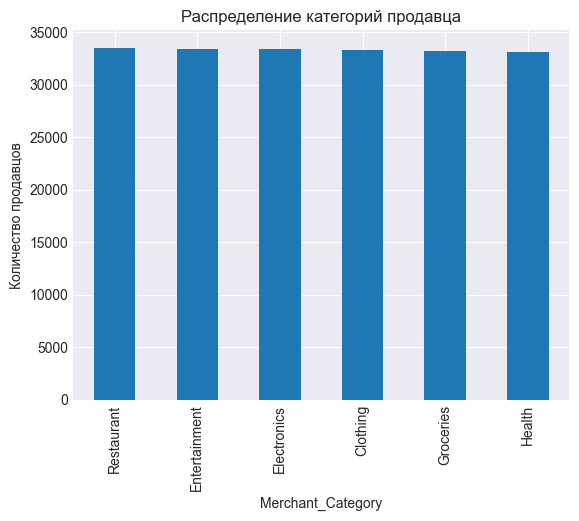

In [17]:
category_distribution('Merchant_Category', 'Распределение категорий продавца', 'Merchant_Category', 'Количество продавцов')

**Вывод**

Анализ распределения категорий продавцов показывает, что в наборе данных представлены шесть категорий: Restaurant, Entertainment, Electronics, Clothing, Groceries и Health. Количество транзакций в каждой категории практически одинаково, что свидетельствует о равномерном распределении категорий продавцов.

Таким образом, признак `Merchant_Category` не имеет выраженного доминирования одной категории и представлен в данных достаточно сбалансированно, что позволяет использовать его в дальнейшем анализе без значительного смещения распределения.


### Транзакционные девайсы

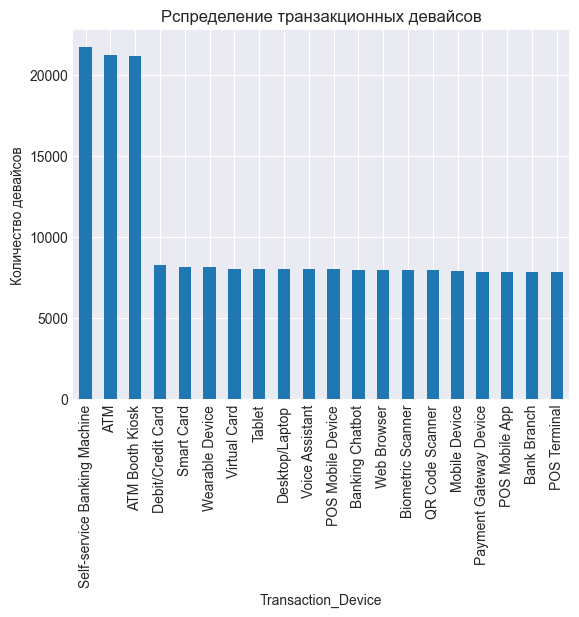

In [18]:
category_distribution('Transaction_Device', 'Рспределение транзакционных девайсов', 'Transaction_Device', 'Количество девайсов')

**Вывод**

Анализ транзакционных устройств показывает, что наибольшее количество операций совершается через устройства самообслуживания и банковскую инфраструктуру, такие как Self-service Banking Machine, ATM и ATM Booth Kiosk. Эти категории заметно выделяются по количеству транзакций.

Остальные типы устройств — мобильные устройства, POS-терминалы, банковские приложения, ноутбуки, планшеты и другие цифровые каналы — представлены примерно на одном уровне и имеют более равномерное распределение.

Таким образом, в наборе данных присутствует широкий спектр устройств для совершения транзакций, однако традиционные банковские каналы самообслуживания остаются наиболее часто используемыми.


### Типы устройства

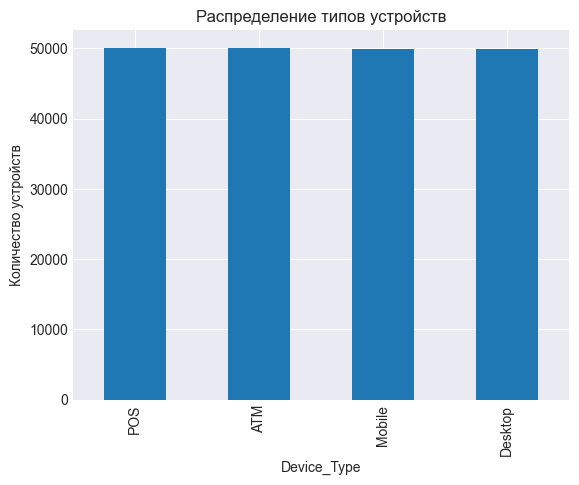

In [19]:
category_distribution('Device_Type', 'Распределение типов устройств', 'Device_Type', 'Количество устройств')

**Вывод**

Анализ распределения типов устройств показывает, что транзакции совершаются через четыре основных типа устройств: POS-терминалы, банкоматы (ATM), мобильные устройства и настольные компьютеры.

Количество транзакций для каждого типа устройства практически одинаково, что свидетельствует о равномерном распределении данного признака в наборе данных.

Таким образом, признак `Device_Type` представлен сбалансировано и не имеет выраженного доминирования одной категории.


### Валюта транзакции

Анализ признака `Transaction_Currency` показал, что в наборе данных используется только одна валюта. Все транзакции представлены в одной валюте, что делает данный признак константным.

В связи с отсутствием вариативности данный признак не несёт аналитической ценности для исследования и не будет использоваться в дальнейшем анализе.


### Государства

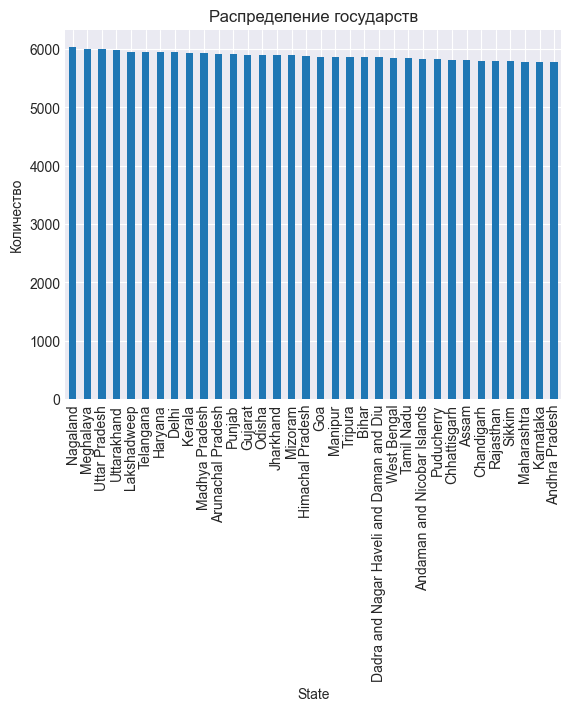

In [20]:
category_distribution('State', 'Распределение государств', 'State', 'Количество')

**Вывод**

Анализ распределения транзакций по штатам показывает, что количество операций в различных регионах распределено практически равномерно. Существенного доминирования отдельных штатов по количеству транзакций не наблюдается.

Такое распределение свидетельствует о сбалансированности данного признака в наборе данных. Следовательно, признак `State` не демонстрирует явных географических перекосов в структуре транзакций.

---

## Анализ численных признаков относительно мошенничества
### Age vs Is_Fraud

Text(0, 0.5, 'Sum Fraud')

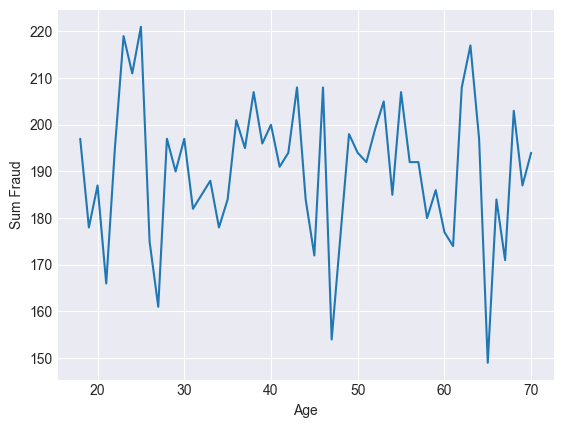

In [21]:
age_vs_fraud = df.groupby('Age')['Is_Fraud'].agg(['sum'])
age_vs_fraud['sum'].plot(kind='line')

plt.xlabel('Age')
plt.ylabel('Sum Fraud')

**Вывод**

Анализ количества мошеннических транзакций по возрасту клиентов не выявил выраженной зависимости между возрастом и вероятностью мошенничества. Количество мошеннических операций распределено относительно равномерно среди различных возрастных групп.

Таким образом, возраст клиента не демонстрирует значимого влияния на вероятность совершения мошеннической транзакции в данном наборе данных.


### Transaction_Amount vs Is_Fraud

C:\Users\persik\AppData\Local\Temp\ipykernel_2832\594221950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_vs_fraud = df.groupby('amount_bin')['Is_Fraud'].mean()


Text(0, 0.5, 'Mean Fraud')

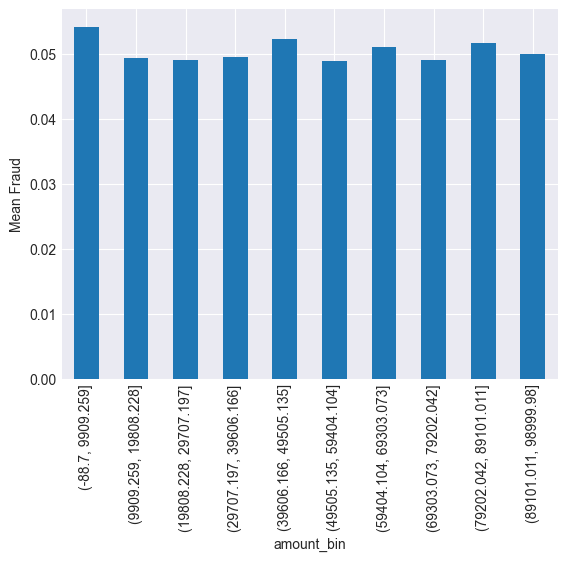

In [22]:
df['amount_bin'] = pd.cut(df['Transaction_Amount'], bins=10)
amount_vs_fraud = df.groupby('amount_bin')['Is_Fraud'].mean()
amount_vs_fraud.plot(kind='bar')

plt.ylabel('Mean Fraud')

**Вывод**

Анализ доли мошеннических транзакций в различных диапазонах сумм операций показывает, что уровень мошенничества остается практически одинаковым для всех интервалов значений.

Доля мошеннических операций колеблется в пределах около 5% и не демонстрирует выраженной зависимости от размера транзакции.

Таким образом, в данном наборе данных сумма транзакции не является значимым фактором, влияющим на вероятность мошенничества.


### Account_Balance vs Fraud

C:\Users\persik\AppData\Local\Temp\ipykernel_2832\652473943.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_vs_fraud = df.groupby('balance_bin')['Is_Fraud'].mean()


Text(0, 0.5, 'Mean Fraud')

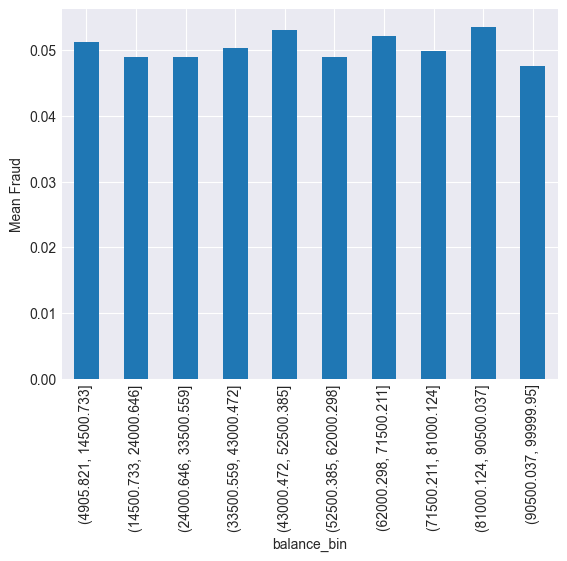

In [23]:
df['balance_bin'] = pd.cut(df['Account_Balance'], bins=10)
balance_vs_fraud = df.groupby('balance_bin')['Is_Fraud'].mean()
balance_vs_fraud.plot(kind='bar')

plt.ylabel('Mean Fraud')

**Вывод**

Анализ доли мошеннических транзакций в различных диапазонах баланса счета показывает, что уровень мошенничества остается практически одинаковым для всех интервалов значений.

Доля мошеннических операций колеблется около среднего значения по выборке (≈5%) и не демонстрирует выраженной зависимости от величины баланса счета клиента.

Таким образом, признак `Account_Balance` не оказывает существенного влияния на вероятность мошеннической транзакции в данном наборе данных.


## Анализ категориальных признаков относительно мошенничества 

### Transaction_Type vs Is_Fraud

Text(0, 0.5, 'Mean')

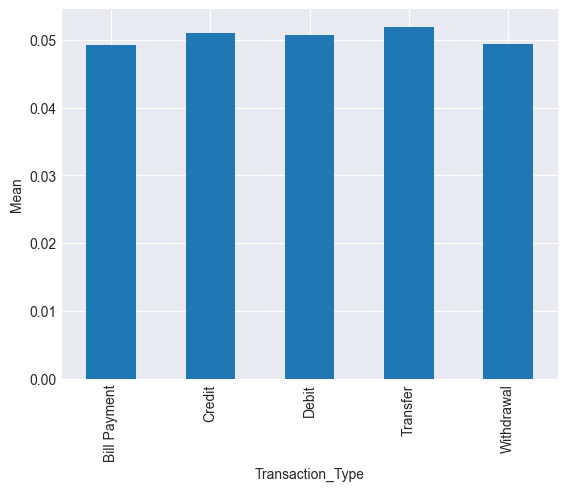

In [24]:
transaction_vs_fraud = df.groupby('Transaction_Type')['Is_Fraud'].agg(['sum', 'count', 'mean'])
transaction_vs_fraud['mean'].plot(kind='bar')

plt.ylabel('Mean')

**Вывод**

Анализ доли мошеннических транзакций в зависимости от типа операции показывает, что уровень мошенничества остается практически одинаковым для всех категорий.

Доля мошеннических операций колеблется вблизи среднего значения по выборке (≈5%) и не демонстрирует выраженной зависимости от типа транзакции.

Таким образом, признак `Transaction_Type` не является значимым фактором, влияющим на вероятность мошенничества в данном наборе данных.


### Device_Type vs Fraud

Text(0, 0.5, 'Mean')

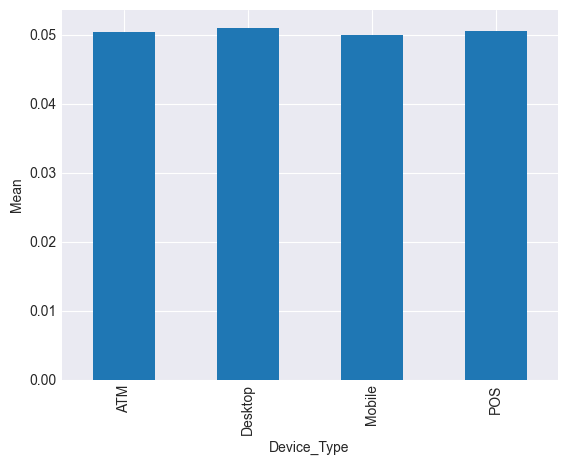

In [25]:
device_vs_fraud = df.groupby('Device_Type')['Is_Fraud'].mean()
device_vs_fraud.plot(kind = 'bar')

plt.ylabel('Mean')

**Вывод**

Анализ доли мошеннических транзакций в зависимости от типа устройств показывает, что уровень мошенничества примерно одинаков для всех устройств.

Доля мошеннических операций колеблется около среднего значения в выборке (≈5%) и не демонстрирует выраженной зависимости от типа устроства.

Таким образом, признак `Device_Type` не является значимым фактором, влияющим на уровень мошеннических операций.

### Merchant_Category vs Fraud

Text(0, 0.5, 'Mean')

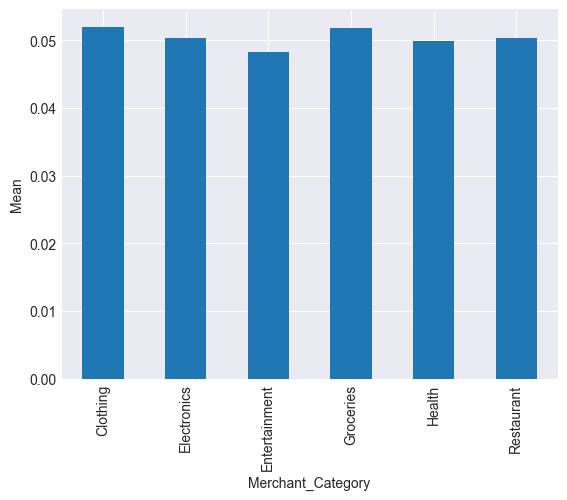

In [26]:
merchant_vs_fraud = df.groupby('Merchant_Category')['Is_Fraud'].mean()
merchant_vs_fraud.plot(kind = 'bar')

plt.ylabel('Mean')

**Вывод**

Анализ доли мошеннических операций относительно типов продавцов демонстрирует, что уровень мошеннических транзакций имеет примено одинаковый уровень для всех типов продавцов.

Доля мошенничества колеблется около среднего значения по всей выборке (≈5%) и не демонстрирует выраженной зависимости от типа продавца.

Таким образом, признак `Merchant_Category` не оказывает существенного влияния на уровень мошеннических транзакций.

### Account_Type vs Fraud

Text(0, 0.5, 'Mean')

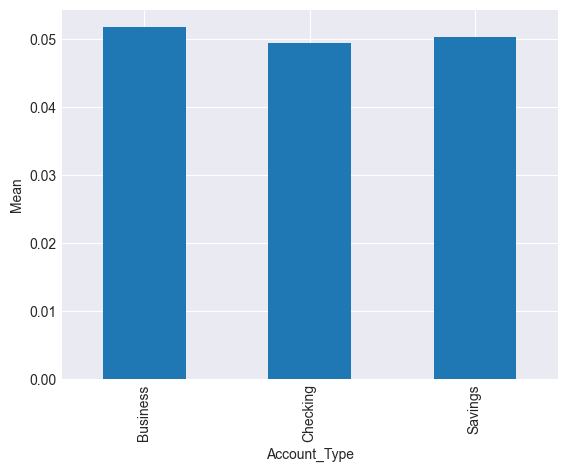

In [27]:
account_vs_fraud = df.groupby('Account_Type')['Is_Fraud'].mean()
account_vs_fraud.plot(kind = 'bar')

plt.ylabel('Mean')

**Вывод**

Анализ доли мошеннических операций относительно типов аккаунтов пользователей демонстрирует, что уровень мошеннических ранзакций примерно одинаков для каждого типа аккаунта.

Доля мошеннических операций колеблется около среднего значения по всей выборке (≈5%) и не показывает выраженной зависимости от типа аккаунта пользователя.

Таким образом, признак `Account_Type` не оказывает существенного влияния на уровень мошеннических транзакций.

### Transaction_Device vs Fraud

Text(0, 0.5, 'Mean')

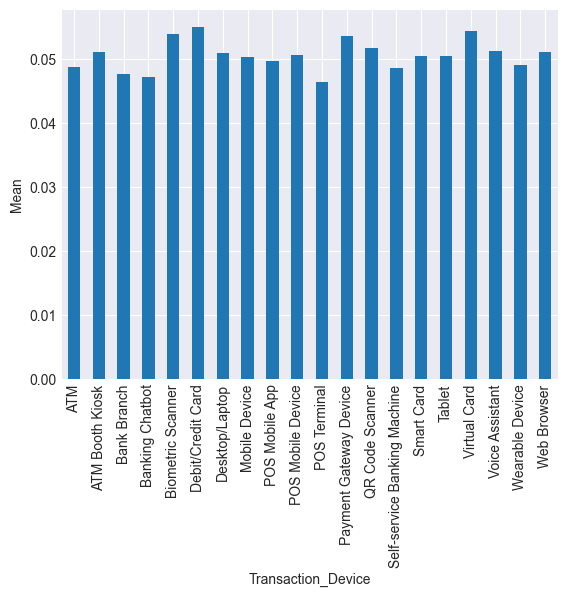

In [28]:
transaction_device_vs_fraud = df.groupby('Transaction_Device')['Is_Fraud'].mean()
transaction_device_vs_fraud.plot(kind = 'bar')

plt.ylabel('Mean')

**Вывод**

Анализ доли мошеннических транзакций в зависимости от используемого устройства показывает незначительные колебания уровня мошенничества между различными категориями.

Тем не менее, различия остаются в пределах общего среднего значения (≈5%) и не демонстрируют выраженной зависимости между типом устройства и вероятностью мошенничества.

Таким образом, признак `Transaction_Device` не оказывает существенного влияния на вероятность мошеннической транзакции в данном наборе данных.

---

## Итоговый вывод

В ходе проведенного разведочного анализа данных не было выявлено выраженных зависимостей между отдельными признаками и вероятностью мошенничества.

Анализ численных признаков (возраст, сумма транзакции, баланс счета) показал, что распределение мошеннических операций остается практически одинаковым во всех диапазонах значений.

Аналогично, категориальные признаки (тип транзакции, устройство, категория продавца и другие) также не демонстрируют значимых различий в доле мошенничества между категориями.

Доля мошеннических транзакций во всех рассмотренных разрезах остается близкой к среднему значению по выборке (≈5%), что указывает на отсутствие сильных однофакторных зависимостей.

Таким образом, можно предположить, что выявление мошеннических операций в данном наборе данных затруднено при анализе отдельных признаков. Вероятно, для обнаружения скрытых закономерностей потребуется использование моделей машинного обучения, способных учитывать комбинации признаков и их взаимосвязи.

---

# Построение модели машинного обучения

## Подготовка данных для моделирования

После проведения разведочного анализа данных (EDA) были выполнены следующие шаги:

- Удалены неинформативные признаки (ID, имена, контакты)
- Исключены признаки с высокой кардинальностью (City, Bank_Branch, Transaction_Location)
- Удалены признаки без полезной информации (Transaction_Date, Transaction_Time)
- Целевая переменная (Is_Fraud) отделена от признаков

Данные были разделены на обучающую и тестовую выборки (80/20).

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [30]:
df_ml = df.drop(columns=['Customer_ID', 
                         'Customer_Name', 
                         'Transaction_ID', 
                         'Merchant_ID', 
                         'Customer_Contact', 
                         'Customer_Email', 
                         'Transaction_Description',
                         'amount_bin',
                         'balance_bin',
                         'City',
                         'Bank_Branch',
                         'Transaction_Location',
                         'Transaction_Date',
                         'Transaction_Time'])

In [31]:
X = df_ml.drop('Is_Fraud', axis = 1)
y = df_ml['Is_Fraud']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

## Кодирование категориальных признаков



In [33]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

Категориальные признаки были преобразованы с использованием one-hot encoding (pd.get_dummies).

Для корректной работы модели выполнено выравнивание колонок между обучающей и тестовой выборками.

In [34]:
X_train.shape

(160000, 70)

In [35]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Масштабирование признаков

In [36]:
scaler = StandardScaler()

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

In [38]:
X_test_scaled = scaler.transform(X_test)



Для корректной работы логистической регрессии признаки были масштабированы с использованием StandardScaler.

## Модель: Logistic Regression

В качестве базовой модели выбрана логистическая регрессия.

Для учета дисбаланса классов использован параметр class_weight='balanced'.

In [39]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.52      0.67     37955
           1       0.05      0.47      0.09      2045

    accuracy                           0.52     40000
   macro avg       0.50      0.50      0.38     40000
weighted avg       0.90      0.52      0.64     40000



## Результаты модели

Модель без учета дисбаланса классов показывала высокую точность (~95%), но полностью игнорировала мошеннические транзакции.

После применения class_weight='balanced' модель начала выявлять около 47% мошеннических операций, однако это привело к увеличению ложных срабатываний и снижению общей точности до ~52%.

Таким образом, наблюдается компромисс между точностью и способностью выявлять мошенничество.

Логистическая регрессия оказалась ограниченной для данной задачи, что указывает на необходимость использования более сложных моделей.

## Модель: Random Forest

In [45]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     37955
           1       0.00      0.00      0.00      2045

    accuracy                           0.95     40000
   macro avg       0.47      0.50      0.49     40000
weighted avg       0.90      0.95      0.92     40000



c:\Users\persik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\persik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\persik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [48]:
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [49]:
y_proba[:10]

array([0.03, 0.08, 0.04, 0.05, 0.04, 0.01, 0.01, 0.06, 0.02, 0.02])

### Настройка порога классификации

In [50]:
y_pred_custom = (y_proba > 0.05).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.62      0.75     37955
           1       0.05      0.37      0.09      2045

    accuracy                           0.61     40000
   macro avg       0.50      0.49      0.42     40000
weighted avg       0.90      0.61      0.72     40000



Анализ вероятностей показал, что модель редко присваивает высокую вероятность мошенничества, поэтому стандартный порог 0.5 не позволяет выявлять fraud.

При снижении порога до 0.05 модель начала выявлять около 37% мошеннических операций, однако это сопровождалось значительным увеличением ложноположительных срабатываний.

Таким образом, наблюдается выраженный компромисс между полнотой (recall) и точностью (precision), что подтверждает слабую разделимость классов в данных.

## ROC-AUC анализ

In [51]:
roc_auc = roc_auc_score(y_test, y_proba)
print(roc_auc)

0.49182540513328254


In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

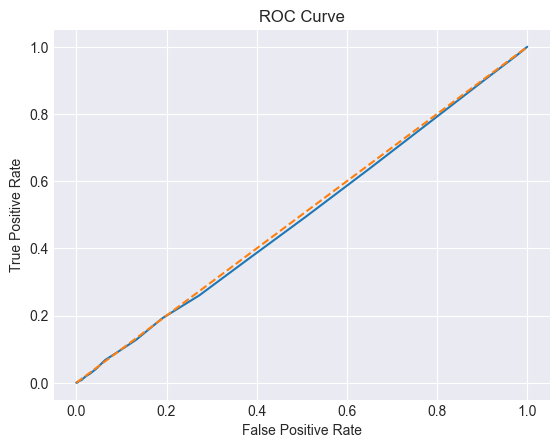

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

In [55]:
for t in [0.01, 0.03, 0.05, 0.1]:
    y_pred_t = (y_proba > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_t))
    print('---------------------')

Threshold: 0.01
              precision    recall  f1-score   support

           0       0.95      0.09      0.17     37955
           1       0.05      0.90      0.10      2045

    accuracy                           0.13     40000
   macro avg       0.50      0.50      0.13     40000
weighted avg       0.90      0.13      0.16     40000

---------------------
Threshold: 0.03
              precision    recall  f1-score   support

           0       0.95      0.35      0.51     37955
           1       0.05      0.64      0.09      2045

    accuracy                           0.36     40000
   macro avg       0.50      0.49      0.30     40000
weighted avg       0.90      0.36      0.49     40000

---------------------
Threshold: 0.05
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     37955
           1       0.05      0.37      0.09      2045

    accuracy                           0.61     40000
   macro avg       0.50      0.49   

## Итоговый анализ модели

Значение ROC-AUC (~0.49) показало, что модель не обладает способностью различать классы и работает на уровне случайного угадывания.

ROC-кривая практически совпадает с диагональю, что подтверждает отсутствие разделимости между мошенническими и обычными транзакциями.

Анализ различных значений порога классификации показал, что увеличение полноты (recall) достигается только за счет резкого роста ложноположительных срабатываний, что делает модель непригодной для практического применения.

Таким образом, проблема заключается не в выборе модели или ее параметров, а в отсутствии информативных признаков в данных.

--- 

# Итоговый вывод

В рамках проекта был проведен разведочный анализ данных (EDA), а также построены и оценены модели машинного обучения для задачи выявления мошеннических транзакций.

На этапе EDA было выявлено, что большинство признаков имеют равномерное распределение и не демонстрируют выраженной зависимости с целевой переменной (Is_Fraud). Это уже на раннем этапе указывало на потенциальную сложность задачи.

В качестве базовых моделей были использованы логистическая регрессия и Random Forest.

Логистическая регрессия без учета дисбаланса классов показала высокую точность (~95%), однако полностью игнорировала мошеннические транзакции. После применения балансировки классов модель начала выявлять fraud, но с существенным ростом ложноположительных срабатываний.

Модель Random Forest не продемонстрировала улучшения и также не смогла эффективно разделять классы.

Дополнительный анализ вероятностей и ROC-AUC показал, что модель не обладает предсказательной способностью (ROC-AUC ≈ 0.49), а ROC-кривая близка к диагонали, что соответствует случайному угадыванию.

Анализ различных порогов классификации показал, что увеличение полноты (recall) возможно только за счет значительного ухудшения точности (precision), что подтверждает отсутствие устойчивых закономерностей в данных.

Таким образом, основное ограничение задачи связано не с выбором модели, а с качеством и информативностью исходных признаков.